# Zero-Shot Person Re-Identification on PRW

End-to-end person search on the PRW dataset using only pretrained models — no task-specific training.

**Task**: given a query crop of a person, find that person across 6,112 whole-scene gallery frames.

**Pipeline**: detect all persons in gallery frames → extract visual features (DINOv2) → optionally enrich with text features (Gemma4 captions + CLIP) → cosine-similarity ranking.

| Config | Detector | Visual | Captions | Purpose |
|--------|----------|--------|----------|---------|
| A | YOLOv12 | DINOv2 | — | Visual-only baseline |
| B | YOLOv12 | DINOv2 | Gemma4 + CLIP | Add text enrichment |
| C | RF-DETR | DINOv2 | Gemma4 + CLIP | Swap detector |

**Before running**, install torch with your CUDA version:
```
uv add torch torchvision --index-url https://download.pytorch.org/whl/cu124
uv sync
```

In [103]:
import os
import re
import sys
import json
import warnings
from pathlib import Path
from typing import Optional

import numpy as np
from scipy.io import loadmat
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import random

sys.path.insert(0, str(Path('.').resolve()))
from utils.eval_function import eval_search_prw

warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


In [104]:
# ── Ablation Configuration ────────────────────────────────────────────────────
# Change RUN_CONFIG to switch ablation variant:
#   'A' → YOLOv12  + DINOv2           (visual-only baseline)
#   'B' → YOLOv12  + DINOv2 + Gemma4  (add text captions)
#   'C' → RF-DETR  + DINOv2 + Gemma4  (swap detector)
# ─────────────────────────────────────────────────────────────────────────────
RUN_CONFIG   = 'C'        # 'A' | 'B' | 'C'| 'D'
DET_THRESH   = 0.3        # eval detection threshold (detector uses 0.3 to keep cache loose. consider to use it to caption less detections.)
ALPHA        = 0.5        # text-feature weight; 0 → pure visual
DATASET_ROOT = 'dataset'

BATCH_DINO         = 32
BATCH_GEMMA        = 4
GEMMA_QUANTIZATION = None    # 4 → 4-bit NF4 | 8 → 8-bit | None → no quantization

SPLIT = "train"
# SPLIT = "test"

CACHE_DIR = Path(f'{SPLIT}_cache')
CACHE_DIR.mkdir(exist_ok=True)

CONFIGS = {
    'A': {'detector': 'yolo12',  'caption': False},
    'B': {'detector': 'rfdetr',  'caption': False},
    'C': {'detector': 'yolo12',  'caption': True},
    'D': {'detector': 'rfdetr',  'caption': True},
}
cfg = CONFIGS[RUN_CONFIG]
print(f"Split   : {SPLIT}")
print(f'Config {RUN_CONFIG}: {cfg}')

Split   : train
Config C: {'detector': 'yolo12', 'caption': True}


## 1. Dataset (must change the description)

Two splits:
- **Gallery** (6,112 test frames): whole-scene images; we detect persons in these.
- **Query** (2,057 images): pre-cropped person images from `dataset/query_box/`.

Annotation boxes are stored as `[x, y, w, h]` in the raw `.mat` files and `query_info.txt`; we convert to `[x1, y1, x2, y2]` throughout.

The query `img_name` is set to the **source frame** name (e.g. `c1s3_016471.jpg`) — this is required by `eval_search_prw` so it can exclude that frame from the gallery during evaluation. `get_image_path` constructs the actual crop path (`{pid}_{frame_base}.jpg` in `query_box/`).

In [105]:
def _cam_id_from_name(name: str) -> int:
    m = re.search(r'c(\d+)', name)
    if m is None:
        raise ValueError(f'Cannot parse camera ID from: {name}')
    return int(m.group(1))


def _xywh_to_xyxy(x: float, y: float, w: float, h: float) -> list:
    return [x, y, x + w, y + h]


class PRWDataset:
    """
    Wraps either the gallery or query split of PRW.

    annotations : list[dict]
        img_name  (str)          — bare filename; for queries this is the SOURCE frame
                                   name used by eval_search_prw for gallery exclusion
        cam_id    (int)          — camera 1–6
        pids      (ndarray|int)  — [N] int32 array (gallery) or scalar int (query)
        boxes     (ndarray)      — [N,4] float32 in x1,y1,x2,y2
    img_prefix : str — directory containing the images
    is_query   : bool — when True, get_image_path reconstructs the crop filename
    """

    def __init__(self, annotations: list, img_prefix: str, is_query: bool = False, split: str = 'test') -> None:
        self.annotations = annotations
        self.img_prefix  = img_prefix
        self.is_query    = is_query
        self.split       = split

    def __len__(self) -> int:
        return len(self.annotations)

    def get_image_path(self, idx: int) -> str:
        ann = self.annotations[idx]
        if self.is_query:
            # img_name = 'c1s3_016471.jpg'  →  crop = '479_c1s3_016471.jpg'
            frame_base = ann['img_name'].rsplit('.', 1)[0]
            id_frame_prefix = f"{(3 - len(str(ann['pids']))) * '0'}{ann['pids']}"
            return os.path.join(self.img_prefix, f"{id_frame_prefix}_{frame_base}.jpg")
        return os.path.join(self.img_prefix, ann['img_name'])

In [106]:
# annotation_keys = ["box_new", "anno_file", "anno_previous"]

def build_gallery_dataset(dataset_root: str = 'dataset', split: str = 'test') -> PRWDataset:
    """
    Build gallery PRWDataset from the split frames. (6112 test)
    Reads frame_{split}.mat and per-frame .mat annotation files.
    """
    root       = Path(dataset_root)
    split_str = split
    split_arr   = loadmat(str(root / f'frame_{split_str}.mat'))[f'img_index_{split_str}'].ravel()
    split_names = [x.item() for x in split_arr]   # bare names without extension

    if split == "train": # i include all the frames containing the query + 1000ish sampled. remove on the final run
        random.seed(42)
        frame_names = list(np.unique([anno["img_name"].split(".")[0] for anno in query_dataset.annotations]))
        split_names = random.choices(split_names, k=1000) # k=1000
        split_names.extend(list(set(frame_names) - set(split_names)))

    ann_dir     = root / 'annotations'
    annotations = []
    for name in tqdm(split_names, desc='Loading gallery annotations'):
        mat     = loadmat(str(ann_dir / f'{name}.jpg.mat'))
        box_new = mat.get("box_new",                         # [N, 5]: pid, x, y, w, h
                          mat.get("anno_file",
                            mat.get("anno_previous", None))) # there exist different names

        pids    = box_new[:, 0].astype(np.int32)
        boxes   = np.stack(
            [box_new[:, 1],
             box_new[:, 2],
             box_new[:, 1] + box_new[:, 3],
             box_new[:, 2] + box_new[:, 4]],
            axis=1,
        ).astype(np.float32)
        annotations.append({
            'img_name': f'{name}.jpg',
            'cam_id':   _cam_id_from_name(name),
            'pids':     pids,
            'boxes':    boxes,
        })

    return PRWDataset(annotations, str((root / 'frames').resolve()), is_query=False, split=split)


def build_query_dataset(dataset_root: str = 'dataset', split: str = 'test') -> PRWDataset:
    """
    Build query PRWDataset from query_info.txt (2,057 queries).
    Line format: pid x y w h frame_name
    """
    root        = Path(dataset_root)
    annotations = []
    split_str = "_train" if split == "train" else ""
    with open(root / f'query_info{split_str}.txt') as f:
        for line in f:
            parts      = line.strip().split()
            pid        = int(parts[0])
            x, y, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            frame_name = parts[5]
            annotations.append({
                'img_name': f'{frame_name}.jpg',   # source frame name — for eval exclusion
                'cam_id':   _cam_id_from_name(frame_name),
                'pids':     pid,                   # scalar int
                'boxes':    np.array([_xywh_to_xyxy(x, y, w, h)], dtype=np.float32),
            })

    return PRWDataset(annotations, str((root / f'query_box{split_str}').resolve()), is_query=True, split=split)

In [107]:
query_dataset   = build_query_dataset(DATASET_ROOT, split=SPLIT)
gallery_dataset = build_gallery_dataset(DATASET_ROOT, split=SPLIT)

print(f'Gallery frames : {len(gallery_dataset)}')    # test: 6112
print(f'Query images   : {len(query_dataset)}')      # test: 2057

g0 = gallery_dataset.annotations[0]
q0 = query_dataset.annotations[0]
print(f'\nGallery[0]: {g0["img_name"]}, cam={g0["cam_id"]}, '
      f'n_persons={len(g0["pids"])}, boxes.shape={g0["boxes"].shape}')
print(f'Query[0]  : {q0["img_name"]}, cam={q0["cam_id"]}, '
      f'pid={q0["pids"]}, box={q0["boxes"]}')
print(f'Query[0] crop path: {query_dataset.get_image_path(0)}')

Loading gallery annotations: 100%|██████████| 2008/2008 [00:00<00:00, 11691.26it/s]

Gallery frames : 2008
Query images   : 1374

Gallery[0]: c5s1_056123.jpg, cam=5, n_persons=2, boxes.shape=(2, 4)
Query[0]  : c5s1_109973.jpg, cam=5, pid=1, box=[[     546.46      349.23      609.44       526.5]]
Query[0] crop path: /home/leonardo/github/ds-dashboard/dataset/query_box_train/001_c5s1_109973.jpg


## 2. Detectors

All detectors share the same interface: `detect_frame(path) → ndarray[n_det, 5]` where columns are `[x1, y1, x2, y2, score]`.

Detection uses a **loose confidence threshold (0.3)** so borderline detections are preserved in the cache. `eval_search_prw` applies `DET_THRESH=0.5` as a second filter — this lets us sweep `DET_THRESH` without re-running the expensive detection step.

In [108]:
class BaseDetector:
    def detect_frame(self, img_path: str) -> np.ndarray:
        """Return [n_det, 5] float32 (x1,y1,x2,y2,score), or [0,5] if none found."""
        raise NotImplementedError

    def detect_batch(self, img_paths: list, desc: str = 'Detecting') -> list:
        return [self.detect_frame(p) for p in tqdm(img_paths, desc=desc, unit='frame')]


class YOLODetector(BaseDetector):
    """YOLOv12 person detector via ultralytics. Downloads weights on first call."""

    _PERSON_CLS = 0   # YOLO class index for 'person'

    def __init__(self, model_name: str = 'yolo12s.pt', conf_thresh: float = 0.3,
                 device: str = DEVICE) -> None:
        from ultralytics import YOLO
        self.model       = YOLO(model_name)
        self.conf_thresh = conf_thresh
        self.device      = device

    def detect_frame(self, img_path: str) -> np.ndarray:
        results = self.model(
            img_path,
            classes=[self._PERSON_CLS],
            conf=self.conf_thresh,
            verbose=False,
            device=self.device,
        )
        r = results[0]
        if len(r.boxes) == 0:
            return np.zeros((0, 5), dtype=np.float32)
        boxes  = r.boxes.xyxy.cpu().numpy()           # [N, 4]
        scores = r.boxes.conf.cpu().numpy()[:, None]  # [N, 1]
        return np.concatenate([boxes, scores], axis=1).astype(np.float32)
    

class RFDETRDetector(BaseDetector):
    """RF-DETR person detector (Roboflow). Requires: uv add rfdetr supervision."""

    from rfdetr.assets.coco_classes import COCO_CLASSES
    _PERSON_CLS = 1 # [k for k,v in COCO_CLASSES.items() if v == "person"][0] 

    def __init__(self, conf_thresh: float = 0.5) -> None:
        from rfdetr import RFDETRBase
        self.model       = RFDETRBase()
        self.model.optimize_for_inference() # actually not affecting that much!
        self.conf_thresh = conf_thresh

    def detect_frame(self, img_path: str) -> np.ndarray:
        img  = Image.open(img_path).convert('RGB')
        dets = self.model.predict(img, threshold=self.conf_thresh)
        # dets is supervision.Detections: .xyxy [N,4], .confidence [N], .class_id [N]
        mask = dets.class_id == self._PERSON_CLS
        if mask.sum() == 0:
            return np.zeros((0, 5), dtype=np.float32)
        boxes  = dets.xyxy[mask]
        scores = dets.confidence[mask][:, None]
        return np.concatenate([boxes, scores], axis=1).astype(np.float32)

In [109]:
def build_detector(config: dict) -> BaseDetector:
    if config['detector'] == 'yolo12':
        return YOLODetector(model_name='yolo12s.pt', device=DEVICE)
    elif config['detector'] == 'rfdetr':
        return RFDETRDetector()
    raise ValueError(f"Unknown detector: {config['detector']}")

## 3. Visual Encoder — DINO

DINOv2-large (ViT-L/14) encodes person crops to 1024-dim CLS token features. These are **L2-normalized** so that dot product = cosine similarity, matching the expectation of `eval_search_prw`.

DINOv2 is preferred over CLIP for the visual component because its features are optimized for fine-grained visual discriminability (patch-level structural features) rather than semantic category matching.

In [110]:
# deprecated: use DINOv3
class DINOv2Encoder:
    """DINOv2-large visual encoder. Outputs L2-normalized 1024-dim patch features."""

    def __init__(self, model_name: str = 'facebook/dinov2-large',
                 batch_size: int = BATCH_DINO, device: str = DEVICE) -> None:
        from transformers import AutoImageProcessor, AutoModel
        self.processor  = AutoImageProcessor.from_pretrained(model_name)
        self.model      = AutoModel.from_pretrained(model_name).to(device).eval()
        self.batch_size = batch_size
        self.device     = device
        self.feat_dim   = 1024
        self.name       = "DINOv2 Encoder"

    @torch.no_grad()
    def encode_images(self, images: list, disable_progress: bool = True) -> np.ndarray:
        """
        Encode a list of PIL images to L2-normalized [N, 1024] float32.
        Processes in batches of self.batch_size to bound GPU memory.
        """
        all_feats = []
        for i in tqdm(range(0, len(images), self.batch_size), desc="Visual features (queries)", 
                      unit="batch", disable=disable_progress):
            batch  = images[i : i + self.batch_size]
            inputs = self.processor(images=batch, return_tensors='pt').to(self.device)
            out    = self.model(**inputs)
            # cls    = out.last_hidden_state[:, 0, :].cpu().float().numpy()  # CLS token
            pooled_patches = out.last_hidden_state[:, 1:, :].mean(dim=1).cpu().float().numpy()  # (B, dim)
            cls = out.pooler_output.cpu().float().numpy() # CLS token
            # concat_feat = np.concatenate([pooled_patches, cls], axis=1).astype(np.float32)
            # all_feats.append(cls)
            all_feats.append(pooled_patches)
            # all_feats.append(concat_feat)
        feats = np.concatenate(all_feats, axis=0)            # [N, 1024]
        norms = np.linalg.norm(feats, axis=1, keepdims=True).clip(min=1e-8)
        return (feats / norms).astype(np.float32) 

    def encode_crops_from_paths(self, paths: list, desc: str = 'DINOv2', **kwargs) -> list:
        """Load images from disk, encode, return list of [D] L2-normalized vectors."""
        images = [Image.open(p).convert('RGB')
                  for p in tqdm(paths, desc=f'Loading ({desc})')]
        feats  = self.encode_images(images, **kwargs)                  # [N, D]
        return [feats[i] for i in range(len(feats))]

class DINOv3Encoder:
    """DINOv3-large visual encoder. Outputs L2-normalized 1024-dim patch features."""

    def __init__(self, model_name: str = 'facebook/dinov3-vitl16-pretrain-lvd1689m',
                 batch_size: int = BATCH_DINO, device: str = DEVICE) -> None:
        from transformers import AutoImageProcessor, AutoModel
        self.processor  = AutoImageProcessor.from_pretrained(model_name)
        self.model      = AutoModel.from_pretrained(model_name).to(device).eval()
        self.batch_size = batch_size
        self.device     = device
        self.feat_dim   = 1024
        self.name       = "DINOv3 Encoder"

    @torch.no_grad()
    def encode_images(self, images: list, disable_progress: bool = True) -> np.ndarray:
        """
        Encode a list of PIL images to L2-normalized [N, 1024] float32.
        Processes in batches of self.batch_size to bound GPU memory.
        """
        all_feats = []
        for i in tqdm(range(0, len(images), self.batch_size), desc="Visual features (queries)", 
                      unit="batch", disable=disable_progress):
            batch  = images[i : i + self.batch_size]
            inputs = self.processor(images=batch, return_tensors='pt').to(self.device)
            out    = self.model(**inputs)
            pooled_patches = out.last_hidden_state[:, 1:, :].mean(dim=1).cpu().float().numpy()  # (B, 1024)
            cls = out.pooler_output.cpu().float().numpy() # cls token, (B, 1024)
            # all_feats.append(cls)                       # pooling on patches outperforms cls token
            all_feats.append(pooled_patches)
        feats = np.concatenate(all_feats, axis=0)            # [N, 1024]
        norms = np.linalg.norm(feats, axis=1, keepdims=True).clip(min=1e-8)
        return (feats / norms).astype(np.float32)

    def encode_crops_from_paths(self, paths: list, desc: str = 'DINOv3', **kwargs) -> list:
        """Load images from disk, encode, return list of [D] L2-normalized vectors."""
        images = [Image.open(p).convert('RGB')
                  for p in tqdm(paths, desc=f'Loading ({desc})')]
        feats  = self.encode_images(images, **kwargs)                  # [N, D]
        return [feats[i] for i in range(len(feats))]

## 4. Caption Generator & Text Encoder

**Idea**: use Gemma4 to generate a one-sentence appearance description per person crop (*"woman in red jacket, dark jeans, black backpack"*). Encode these captions with CLIP's text encoder, then fuse with DINOv2 visual features.

Text descriptions are **camera-invariant** in a way that pixel features are not: clothing color is the same description under different lighting conditions. This provides a complementary signal for cross-camera matching.

Captions are generated **once per crop** (O(total detections)), not per query-gallery pair — making this computationally tractable.

The `alpha` hyperparameter controls the text contribution:
- `alpha=0` → pure visual (same as Config A)
- `alpha=1` → equal weight to text features
- Alpha sweep in Section 8 finds the optimal value.

In [111]:
class GemmaCaptioner:
    """
    Generates appearance captions for person crops using google/gemma-4-e2b-it.

    Uses AutoModelForImageTextToText + apply_chat_template (standard HF multimodal API).
    Captions are cached to disk — this is the most expensive stage (~hours on GPU).

    quantization : int | None
        4  → 4-bit NF4 (bitsandbytes, lowest VRAM, slight quality drop)
        8  → 8-bit (bitsandbytes, moderate VRAM, minimal quality drop)
        None → bfloat16 full-precision (best quality, highest VRAM)
    """

    # PROMPT = (
    #     'Describe this person\'s appearance in one sentence. '
    #     'Focus on: gender, clothing colors, clothing type (shirt/jacket/dress/coat), '
    #     'footwear color, and any distinctive accessories (bag, hat, umbrella). '
    #     'Be concise and specific, do not use filler phrases nor write full sentences. '
    # )

    PROMPT = (
        'Describe this person\'s appearance in one sentence. '
        'Focus on: gender, clothing colors, clothing type (shirt/jacket/dress/coat), '
        'footwear color, and any distinctive accessories (bag, hat, umbrella). '
        'Be concise and specific.'
    )

    def __init__(self, model_name: str = 'google/gemma-4-e2b-it',
                 quantization: Optional[int] = None,
                 device: str = DEVICE) -> None:
        from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

        self.processor = AutoProcessor.from_pretrained(model_name)

        bnb_config = None
        if quantization == 4: # we introduced quantization for speeding up the inference; got worse lol
            bnb_config = BitsAndBytesConfig( # think of using unsloth (claiming 2x inference speed)
                load_in_4bit=True,
                bnb_4bit_quant_type='nf4',
                bnb_4bit_use_double_quant=True,
                bnb_4bit_compute_dtype=torch.bfloat16,
            )
        elif quantization == 8:
            bnb_config = BitsAndBytesConfig(load_in_8bit=True)
        elif quantization is not None:
            raise ValueError(
                f'Unsupported quantization: {quantization!r}. Use 4, 8, or None.'
            )

        model_kwargs = {'device_map': 'auto'}
        if bnb_config is not None:
            model_kwargs['quantization_config'] = bnb_config
        else:
            model_kwargs['torch_dtype'] = torch.bfloat16

        self.model = AutoModelForImageTextToText.from_pretrained(
            model_name, **model_kwargs
        ).eval()

    @torch.no_grad()
    def caption_single(self, image: Image.Image) -> str:
        messages = [
            {
                'role': 'user',
                'content': [
                    {'type': 'image'},              # placeholder; image passed to processor
                    {'type': 'text', 'text': self.PROMPT},
                ],
            }
        ]
        text   = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inputs = self.processor(
            text=text, images=[image], return_tensors='pt'
        ).to(self.model.device)
        n_in   = inputs['input_ids'].shape[1]
        out    = self.model.generate(**inputs, max_new_tokens=60, do_sample=False)
        return self.processor.decode(out[0][n_in:], skip_special_tokens=True).strip()

    def caption_batch(self, images: list, batch_size: int = BATCH_GEMMA,
                      desc: str = 'Gemma captioning') -> list:
        captions = []
        for img in tqdm(images, desc=desc):
            try:
                captions.append(self.caption_single(img))
            except Exception:
                captions.append('')   # fallback for degenerate crops
        return captions

In [112]:
class CLIPTextEncoder:
    """CLIP-ViT-L/14 text encoder. Outputs L2-normalized 768-dim text features."""

    def __init__(self, model_name: str = 'openai/clip-vit-large-patch14',
                 batch_size: int = 64, device: str = DEVICE) -> None:
        from transformers import CLIPModel, CLIPTokenizer
        self.tokenizer  = CLIPTokenizer.from_pretrained(model_name)
        self.model      = CLIPModel.from_pretrained(model_name).to(device).eval()
        self.batch_size = batch_size
        self.device     = device
        self.feat_dim   = 768

    @torch.no_grad()
    def encode_texts(self, captions: list) -> np.ndarray:
        """Return L2-normalized [N, 768] float32 array."""
        all_feats = []
        for i in range(0, len(captions), self.batch_size):
            batch  = captions[i : i + self.batch_size]
            inputs = self.tokenizer(
                batch, padding=True, truncation=True, max_length=77, return_tensors='pt'
            ).to(self.device)
            out = self.model.get_text_features(**inputs)
            # feats  = out.pooler_output # we take the pool output layer, representing the encoding of the whole sentence
            feats  = out.last_hidden_state[:, :, :].mean(dim=1)
            feats = feats.cpu().float().numpy()
            all_feats.append(feats)
        feats = np.concatenate(all_feats, axis=0)            # [N, 768]
        norms = np.linalg.norm(feats, axis=1, keepdims=True).clip(min=1e-8)
        return (feats / norms).astype(np.float32)

def fuse_features(visual_feats: np.ndarray, text_feats: np.ndarray,
                  alpha: float = ALPHA, shared_space: bool = False) -> np.ndarray:
    """
    Fuse visual and text features.

    Two modes:
      shared_space=False (default): concatenation + L2-norm.
          Output dim = visual_dim + text_dim.
          Suitable for heterogeneous encoders (e.g. DINOv2 + CLIP).
          Result: L2_normalize(concat((1-alpha) * visual, alpha * text))

      shared_space=True: weighted sum + L2-norm.
          Output dim = visual_dim (= text_dim, must match).
          Suitable for same-space encoders (e.g. CLIP image + CLIP text).
          Result: L2_normalize((1-alpha) * visual + alpha * text)

    Supports both 1D (single vector) and 2D (batch) inputs.
    alpha=0 zeroes out text but keeps the same output dimension — use
    gallery_text_feats=None in build_final_gallery_feats to skip fusion entirely.
    """
    scalar = visual_feats.ndim == 1
    if scalar:
        visual_feats = visual_feats[None]
        text_feats   = text_feats[None]

    if shared_space:
        assert visual_feats.shape[1] == text_feats.shape[1], (
            f"shared_space=True requires matching feature dims, "
            f"got visual={visual_feats.shape[1]} vs text={text_feats.shape[1]}"
        )
        fused = ((1 - alpha) * visual_feats + alpha * text_feats).astype(np.float32)
    else:
        fused = np.concatenate(
            [(1 - alpha) * visual_feats, alpha * text_feats], axis=1
        ).astype(np.float32)

    norms = np.linalg.norm(fused, axis=1, keepdims=True).clip(min=1e-8)
    fused = fused / norms
    return fused[0] if scalar else fused

## Just another text encoder

In [113]:
class BGEM3TextEncoder:
    """
    BAAI/bge-m3 text encoder.
    Outputs L2-normalized 1024-dim text features via mean pooling.
    """

    def __init__(self, model_name: str = 'BAAI/bge-m3',
                 batch_size: int = 64, device: str = DEVICE) -> None:
        from transformers import AutoTokenizer, AutoModel
        self.tokenizer  = AutoTokenizer.from_pretrained(model_name)
        self.model      = AutoModel.from_pretrained(model_name).to(device).eval()
        self.batch_size = batch_size
        self.device     = device
        self.feat_dim   = 1024

    @staticmethod
    def _mean_pool(last_hidden_state: torch.Tensor,
                   attention_mask: torch.Tensor) -> torch.Tensor:
        """Mean-pool token embeddings, ignoring padding tokens."""
        mask = attention_mask.unsqueeze(-1).float()           # (B, T, 1)
        summed = (last_hidden_state * mask).sum(dim=1)        # (B, D)
        counts = mask.sum(dim=1).clip(min=1e-8)               # (B, 1)
        return summed / counts                                 # (B, D)

    @torch.no_grad()
    def encode_texts(self, captions: list) -> np.ndarray:
        """Return L2-normalized [N, 1024] float32 array."""
        all_feats = []
        for i in range(0, len(captions), self.batch_size):
            batch  = captions[i : i + self.batch_size]
            inputs = self.tokenizer(
                batch, padding=True, truncation=True, max_length=512,
                return_tensors='pt'
            ).to(self.device)
            out   = self.model(**inputs)
            feats = self._mean_pool(out.last_hidden_state, # last_hidden_state outperforms pooler_output for top-1 accuracy
                                    inputs['attention_mask'])  # (B, 1024)
            all_feats.append(feats.cpu().float().numpy())
        feats = np.concatenate(all_feats, axis=0)
        norms = np.linalg.norm(feats, axis=1, keepdims=True).clip(min=1e-8)
        return (feats / norms).astype(np.float32)

## CLIP Encoder
We build CLIP performing the embedding in a shared space.

In [114]:
class CLIPEncoder:
    """
    CLIP-ViT-L/14 unified encoder.
    Encodes both images and captions to L2-normalized 768-dim features
    in the same embedding space.
    """

    def __init__(self, model_name: str = 'openai/clip-vit-large-patch14',
                 batch_size: int = 64, device: str = DEVICE) -> None:
        from transformers import CLIPModel, CLIPTokenizer, CLIPProcessor
        self.tokenizer  = CLIPTokenizer.from_pretrained(model_name)
        self.processor  = CLIPProcessor.from_pretrained(model_name)
        self.model      = CLIPModel.from_pretrained(model_name).to(device).eval()
        self.batch_size = batch_size
        self.device     = device
        self.feat_dim   = 768
        self.name       = "CLIP Encoder"

    @staticmethod
    def _l2_normalize(feats: np.ndarray) -> np.ndarray:
        norms = np.linalg.norm(feats, axis=1, keepdims=True).clip(min=1e-8)
        return (feats / norms).astype(np.float32)

    @torch.no_grad()
    def encode_texts(self, captions: list) -> np.ndarray:
        """Return L2-normalized [N, 768] float32 array from text captions."""
        all_feats = []
        for i in range(0, len(captions), self.batch_size):
            batch  = captions[i : i + self.batch_size]
            inputs = self.tokenizer(
                batch, padding=True, truncation=True,
                max_length=77, return_tensors='pt'
            ).to(self.device)
            feats  = self.model.get_text_features(**inputs).pooler_output # we take the pool output layer, representing the encoding of the whole sentence   # (B, 768), already projected
            all_feats.append(feats.cpu().float().numpy())
        return self._l2_normalize(np.concatenate(all_feats, axis=0))

    @torch.no_grad()
    def encode_images(self, images: list, disable_progress: bool = True) -> np.ndarray:
        """Return L2-normalized [N, 768] float32 array from PIL images."""
        all_feats = []
        for i in tqdm(range(0, len(images), self.batch_size), desc="Visual features (queries)", 
                      unit="batch", disable=disable_progress):
            batch  = images[i : i + self.batch_size]
            inputs = self.processor(
                images=batch, return_tensors='pt'
            ).to(self.device)
            feats  = self.model.get_image_features(**inputs).pooler_output  # (B, 768), already projected
            all_feats.append(feats.cpu().float().numpy())
        return self._l2_normalize(np.concatenate(all_feats, axis=0))

    def encode_crops_from_paths(self, paths: list, desc: str = 'CLIP', **kwargs) -> list:
        """Load images from disk, encode, return list of [D] L2-normalized vectors."""
        images = [Image.open(p).convert('RGB')
                  for p in tqdm(paths, desc=f'Loading ({desc})')]
        feats  = self.encode_images(images, **kwargs)                   # [N, D]
        return [feats[i] for i in range(len(feats))]

## SigLIP Encoder
Siglip encoder

In [115]:
class SigLIP2Encoder:
    """
    SigLIP2 unified encoder (google/siglip2-so400m-patch14-384).
    Encodes both images and captions to L2-normalized 1152-dim features
    in the same shared embedding space.

    Critical training-time defaults that must be preserved:
      - text: padding="max_length", max_length=64, truncation=True
      - text lowercasing is applied automatically by Siglip2Processor
    """

    def __init__(self, model_name: str = 'google/siglip2-so400m-patch14-384',
                 batch_size: int = 32, device: str = DEVICE) -> None:
        from transformers import AutoProcessor, AutoModel
        self.processor  = AutoProcessor.from_pretrained(model_name)
        self.model      = AutoModel.from_pretrained(model_name).to(device).eval()
        self.batch_size = batch_size
        self.device     = device
        self.feat_dim   = 1152   # SO400M projection dim
        self.name       = "SigLIP2 Encoder"

    @staticmethod
    def _l2_normalize(feats: np.ndarray) -> np.ndarray:
        norms = np.linalg.norm(feats, axis=1, keepdims=True).clip(min=1e-8)
        return (feats / norms).astype(np.float32)

    @torch.no_grad()
    def encode_texts(self, captions: list) -> np.ndarray:
        """
        Return L2-normalized [N, 1152] float32 array from text captions.
        Lowercasing and padding to max_length=64 are applied automatically
        by the processor — do not override these.
        """
        all_feats = []
        for i in range(0, len(captions), self.batch_size):
            batch  = captions[i : i + self.batch_size]
            inputs = self.processor(
                text=batch,
                padding='max_length',   # mandatory: matches training
                max_length=64,          # mandatory: matches training
                truncation=True,
                return_tensors='pt'
            ).to(self.device)
            feats = self.model.get_text_features(**inputs).pooler_output  # (B, 1152)
            all_feats.append(feats.cpu().float().numpy())
        return self._l2_normalize(np.concatenate(all_feats, axis=0))

    @torch.no_grad()
    def encode_images(self, images: list, disable_progress: bool = True) -> np.ndarray:
        """Return L2-normalized [N, 1152] float32 array from PIL images."""
        all_feats = []
        for i in tqdm(range(0, len(images), self.batch_size), desc="Visual features (queries)", 
                      unit="batch", disable=disable_progress):
            batch  = images[i : i + self.batch_size]
            inputs = self.processor(
                images=batch,
                return_tensors='pt'
            ).to(self.device)
            feats = self.model.get_image_features(**inputs).pooler_output  # (B, 1152)
            all_feats.append(feats.cpu().float().numpy())
        return self._l2_normalize(np.concatenate(all_feats, axis=0))

    def encode_crops_from_paths(self, paths: list, desc: str = 'SigLIP2', **kwargs) -> list:
        """Load images from disk, encode, return list of [D] L2-normalized vectors."""
        images = [Image.open(p).convert('RGB')
                  for p in tqdm(paths, desc=f'Loading ({desc})')]
        feats  = self.encode_images(images, **kwargs)                  # [N, D]
        return [feats[i] for i in range(len(feats))]

## TIPSv2 Encoder
just another google encoder bro

In [116]:
class TIPSv2Encoder:
    """
    TIPSv2-SO400m/14 unified encoder (google/tipsv2-so400m14).
    Encodes both images and captions to L2-normalized 1152-dim features
    in the same shared embedding space, with explicit patch-text alignment.

    Image preprocessing: Resize to 448x448, ToTensor() — raw [0,1] range.
    NO ImageNet normalization.

    Outputs:
      - encode_texts()  → [N, 1152] — global text embeddings
      - encode_images() → [N, 1152] — global image embeddings (CLS token)
      - encode_images_with_patches() → ([N, 1152], [N, 1024, 1152])
            for experiments using spatial patch features
    """

    def __init__(self, model_name: str = 'google/tipsv2-so400m14',
                 image_size: int = 448,
                 batch_size: int = 32, device: str = DEVICE) -> None:
        from torchvision import transforms
        from transformers import AutoModel
        self.model = AutoModel.from_pretrained(
            model_name, trust_remote_code=True
        ).to(device).eval()
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),             # [0, 1], no ImageNet normalization according to hf model card
        ])
        self.batch_size = batch_size
        self.device     = device
        self.feat_dim   = 1152
        self.name       = "TIPSv2 Encoder"

    @staticmethod
    def _l2_normalize(feats: np.ndarray) -> np.ndarray:
        norms = np.linalg.norm(feats, axis=1, keepdims=True).clip(min=1e-8)
        return (feats / norms).astype(np.float32)

    @torch.no_grad()
    def encode_texts(self, captions: list) -> np.ndarray:
        """Return L2-normalized [N, 1152] float32 array from text captions."""
        all_feats = []
        for i in range(0, len(captions), self.batch_size):
            batch = captions[i : i + self.batch_size]
            feats = self.model.encode_text(batch)            # (B, 1152), internal tokenization
            all_feats.append(feats.cpu().float().numpy())
        return self._l2_normalize(np.concatenate(all_feats, axis=0))

    @torch.no_grad()
    def encode_images(self, images: list, disable_progress: bool = True) -> np.ndarray:
        """
        Return L2-normalized [N, 1152] float32 array from PIL images.
        Uses CLS token only — drop-in replacement for SigLIP2/CLIP encoders.
        """
        all_feats = []
        for i in tqdm(range(0, len(images), self.batch_size), desc="Visual features (queries)", 
                      unit="batch", disable=disable_progress):
            batch        = images[i : i + self.batch_size]
            pixel_values = torch.stack(
                [self.transform(img) for img in batch]
            ).to(self.device)                                # (B, 3, 448, 448)
            out   = self.model.encode_image(pixel_values)
            feats = out.cls_token[:, 0, :]                  # (B, 1152) # cls_token outperforms pooling on patch_tokens
            all_feats.append(feats.cpu().float().numpy())
        return self._l2_normalize(np.concatenate(all_feats, axis=0))

    def encode_crops_from_paths(self, paths: list, desc: str = 'TIPSv2', **kwargs) -> list:
        """Load images from disk, encode, return list of [D] L2-normalized vectors."""
        images = [Image.open(p).convert('RGB')
                  for p in tqdm(paths, desc=f'Loading ({desc})')]
        feats  = self.encode_images(images, **kwargs)                 # [N, D]
        return [feats[i] for i in range(len(feats))]

## 5. Gallery Processing

Five stages, each with disk caching (named by `RUN_CONFIG` to avoid cross-contamination):

1. **Detection** — run detector on all 6,112 frames → `[n_det, 5]` per frame
2. **Visual features** — DINOv2 on each detected crop → `[n_det, 1024]` per frame
3. **Captions** — Gemma4 description per crop → `list[list[str]]` (Configs B/C only)
4. **Text features** — CLIP text encoder on captions → `[n_det, 768]` per frame (B/C only)
5. **Fusion** — `L2_normalize(concat(visual, alpha * text))` per frame

In [117]:
def _crop_persons(frame: Image.Image, dets: np.ndarray) -> list:
    """Crop detected bounding boxes from a PIL frame, clipping to image bounds."""
    W, H  = frame.size
    crops = []
    for x1, y1, x2, y2, _ in dets:
        x1c, y1c = max(0, int(x1)), max(0, int(y1))
        x2c, y2c = min(W, int(x2)), min(H, int(y2))
        if x2c > x1c and y2c > y1c:
            crops.append(frame.crop((x1c, y1c, x2c, y2c)))
        else:
            crops.append(Image.new('RGB', (64, 128)))   # degenerate bbox fallback
    return crops


def run_gallery_detection(gallery_dataset: PRWDataset, detector: BaseDetector,
                          cache_path: Path, force: bool = False) -> list:
    """
    Detect persons in all gallery frames. Returns list of [n_det, 5] float32 arrays.
    Caches results as a numpy object array; loads from cache if available.
    """
    if cache_path.exists() and not force:
        print(f'Loading detections from cache: {cache_path}')
        return list(np.load(str(cache_path), allow_pickle=True))

    img_paths    = [gallery_dataset.get_image_path(i) for i in range(len(gallery_dataset))]
    gallery_dets = detector.detect_batch(img_paths, desc='Detecting gallery')

    arr = np.empty(len(gallery_dets), dtype=object)
    for i, d in enumerate(gallery_dets):
        arr[i] = d if d.shape[0] > 0 else np.zeros((0, 5), dtype=np.float32)
    np.save(str(cache_path), arr)
    print(f'Saved detections \u2192 {cache_path}')
    return list(arr)

In [118]:
def run_gallery_visual_features(gallery_dataset: PRWDataset, gallery_dets: list,
                                encoder: DINOv2Encoder, cache_path: Path,
                                force: bool = False) -> list:
    """
    Extract DINOv2 CLS features for every detected person crop.
    Returns list of [n_det, D] L2-normalized float32 arrays; [0, D] for empty frames.
    """
    if cache_path.exists() and not force:
        print(f'Loading visual features from cache: {cache_path}')
        return list(np.load(str(cache_path), allow_pickle=True))

    D = encoder.feat_dim
    gallery_feats = []
    for i in tqdm(range(len(gallery_dataset)), desc='Visual features (gallery)', unit="frame"):
        dets = gallery_dets[i]
        if dets.shape[0] == 0:
            gallery_feats.append(np.zeros((0, D), dtype=np.float32))
            continue
        frame = Image.open(gallery_dataset.get_image_path(i)).convert('RGB')
        crops = _crop_persons(frame, dets)
        gallery_feats.append(encoder.encode_images(crops))   # [n_det, D]

    arr = np.empty(len(gallery_feats), dtype=object)
    for i, f in enumerate(gallery_feats):
        arr[i] = f
    np.save(str(cache_path), arr)
    print(f'Saved visual features \u2192 {cache_path}')
    return list(arr)

In [119]:
def run_gallery_captions(gallery_dataset: PRWDataset, gallery_dets: list,
                         captioner: GemmaCaptioner, cache_path: Path,
                         force: bool = False) -> list:
    """
    Generate Gemma4 captions for all detected person crops.
    Returns list[list[str]]: outer = frames, inner = one caption per detection.
    Cached as JSON — this is the most time-consuming stage.
    """
    if cache_path.exists() and not force:
        print(f'Loading captions from cache: {cache_path}')
        with open(cache_path) as f:
            return json.load(f)

    gallery_captions = []
    for i in tqdm(range(len(gallery_dataset)), desc='Gemma captioning (gallery)'):
        dets = gallery_dets[i]
        if dets.shape[0] == 0:
            gallery_captions.append([])
            continue
        frame = Image.open(gallery_dataset.get_image_path(i)).convert('RGB')
        crops = _crop_persons(frame, dets)
        gallery_captions.append(captioner.caption_batch(crops, desc=''))

    with open(cache_path, 'w') as f:
        json.dump(gallery_captions, f)
    print(f'Saved captions \u2192 {cache_path}')
    return gallery_captions


def run_gallery_text_features(gallery_captions: list, text_encoder: CLIPTextEncoder,
                              cache_path: Path, force: bool = False) -> list:
    """
    CLIP-encode gallery captions to L2-normalized text features.
    Returns list of [n_det, D_text] float32 arrays; [0, D_text] for empty frames.
    """
    D_text = text_encoder.feat_dim
    if cache_path.exists() and not force:
        print(f'Loading text features from cache: {cache_path}')
        return list(np.load(str(cache_path), allow_pickle=True))

    gallery_text_feats = []
    for caps in tqdm(gallery_captions, desc='CLIP text features (gallery)'):
        if len(caps) == 0:
            gallery_text_feats.append(np.zeros((0, D_text), dtype=np.float32))
        else:
            gallery_text_feats.append(text_encoder.encode_texts(caps))

    arr = np.empty(len(gallery_text_feats), dtype=object)
    for i, f in enumerate(gallery_text_feats):
        arr[i] = f
    np.save(str(cache_path), arr)
    print(f'Saved text features \u2192 {cache_path}')
    return list(arr)


def build_final_gallery_feats(gallery_vis_feats: list,
                              gallery_text_feats: Optional[list],
                              alpha: float = ALPHA) -> list:
    """
    Fuse visual and text features per frame.
    When gallery_text_feats is None (Config A), returns visual features unchanged.
    Otherwise always fuses (even at alpha=0) to keep dims consistent with queries.
    """
    if gallery_text_feats is None:
        return gallery_vis_feats
    fused = []
    for vis, txt in zip(gallery_vis_feats, gallery_text_feats):
        if vis.shape[0] == 0:
            fused.append(np.zeros((0, vis.shape[1] + txt.shape[1]), dtype=np.float32))
        else:
            # DEBUG
            # print(vis.shape)
            # print(txt.shape)
            fused.append(fuse_features(vis, txt, alpha))
    return fused

In [120]:
ILLEGAL_WORDS = ["blurred", "blur", "sorry", "discernible"]

def contains_illegal(text: str) -> bool:
    text = text.lower()
    return any(word in text for word in ILLEGAL_WORDS)

def polish_caps(caps: list, is_query: bool = False) -> list:
    """
    Remove noisy captions.
    """
    no_sorry_no_blurry_caps = caps.copy()
    polished_captions = 0

    for f, frame in enumerate(no_sorry_no_blurry_caps):

        if is_query:
            if contains_illegal(frame):
                no_sorry_no_blurry_caps[f] = ""
                polished_captions += 1

        else:
            for c, caption in enumerate(frame):
                if contains_illegal(caption):
                    no_sorry_no_blurry_caps[f][c] = ""
                    polished_captions += 1

    print(f"Removed {polished_captions} captions.")
    return no_sorry_no_blurry_caps

In [121]:
# ── Cache paths (named by config to prevent cross-contamination) ──────────────
DETS_CACHE = CACHE_DIR / f'gallery_dets_{RUN_CONFIG}.npy'
VIS_CACHE  = CACHE_DIR / f'gallery_vis_{RUN_CONFIG}.npy'
CAPS_CACHE = CACHE_DIR / f'gallery_caps_{RUN_CONFIG}.json'
TXT_CACHE  = CACHE_DIR / f'gallery_txt_{RUN_CONFIG}.npy'

# ── Instantiate models ────────────────────────────────────────────────────────
detector = build_detector(cfg)
# dino_enc = DINOv2Encoder(device=DEVICE)
dino_enc = DINOv3Encoder(device=DEVICE)
# dino_enc = CLIPEncoder(device=DEVICE)
# dino_enc = SigLIP2Encoder(device=DEVICE)
# dino_enc = TIPSv2Encoder(device=DEVICE)

# ── Stage 1: Detection ────────────────────────────────────────────────────────
gallery_dets = run_gallery_detection(gallery_dataset, detector, DETS_CACHE)

# ── Stage 2: Visual features ──────────────────────────────────────────────────
gallery_vis_feats = run_gallery_visual_features(
    gallery_dataset, gallery_dets, dino_enc, VIS_CACHE
)

# ── Stages 3 & 4: Captions + text features (Configs B & C only) ───────────────
gallery_text_feats = None
if cfg['caption']:
    captioner    = GemmaCaptioner(device=DEVICE, quantization=GEMMA_QUANTIZATION)
    # GemmaCaptioner.model = torch.compile(GemmaCaptioner.model) # should speed up computation!
    text_encoder = CLIPTextEncoder(device=DEVICE)
    # text_encoder = dino_enc
    # text_encoder = BGEM3TextEncoder(device=DEVICE)
    gallery_caps = polish_caps(run_gallery_captions(
        gallery_dataset, gallery_dets, captioner, CAPS_CACHE
    ))
    gallery_text_feats = run_gallery_text_features(gallery_caps, text_encoder, TXT_CACHE)

# ── Stage 5: Fuse ─────────────────────────────────────────────────────────────
gallery_feats = build_final_gallery_feats(gallery_vis_feats, gallery_text_feats, ALPHA)

sample = next(f for f in gallery_feats if f.shape[0] > 0)
print(f'gallery_feats sample shape: {sample.shape}')

Loading weights: 100%|██████████| 415/415 [00:00<00:00, 19872.54it/s]


Loading detections from cache: train_cache/gallery_dets_C.npy
Loading visual features from cache: train_cache/gallery_vis_C.npy


[transformers] Current model requires 6178 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.
Loading weights: 100%|██████████| 590/590 [00:00<00:00, 20292.58it/s]


Loading captions from cache: train_cache/gallery_caps_C.json
Removed 446 captions.
Loading text features from cache: train_cache/gallery_txt_C.npy


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 4 and the array at index 1 has size 3

In [ ]:
persons = 0
for x in gallery_dets:
    persons += len(x)

captions = 0
if cfg["caption"] == True:
    for x in gallery_caps:
        captions += len(x)

    assert persons == captions, ("There is a mismatch between captions and persons,"
                                 f"Persons: {persons}, Captions: {captions}"
                                 "you might have to run them again :(")

print(f"detected persons:       {persons}")
print(f"captions        :       {captions}")
print(f"avg persons per frame:  {persons/len(gallery_dets)}")


detected persons:       7012
captions        :       7012
avg persons per frame:  3.49203187250996


## 5.1 Checking captions
### to do: here you can add a function that plots some cropped persons together with the caption generated by gemma4. if cfg["caption"] == False, then simply plot the crops without the caption.

In [ ]:
def plot_caption_samples(n_samples: int = 12, n_cols: int = 4) -> None:
    import textwrap
    caps = gallery_caps if cfg['caption'] else None

    candidates = [
        (fi, di)
        for fi, dets in enumerate(gallery_dets)
        for di in range(len(dets))
    ]
    k = min(n_samples, len(candidates))
    sampled = random.sample(candidates, k)

    n_rows = (k + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten()

    for ax, (fi, di) in zip(axes, sampled):
        ann = gallery_dataset.annotations[fi]
        frame = Image.open(os.path.join(gallery_dataset.img_prefix, ann['img_name']))
        x1, y1, x2, y2 = (int(v) for v in gallery_dets[fi][di][:4])
        crop = frame.crop((max(0, x1), max(0, y1), x2, y2))
        ax.imshow(crop)
        ax.axis('off')
        if caps is not None:
            title = '\n'.join(textwrap.wrap(caps[fi][di], width=28))
        else:
            title = ann['img_name']
        ax.set_title(title, fontsize=7)

    for ax in axes[k:]:
        ax.axis('off')

    suptitle = 'Caption samples' if caps is not None else 'Crop samples (no captions)'
    plt.suptitle(suptitle, fontsize=10)
    plt.tight_layout()
    plt.show()

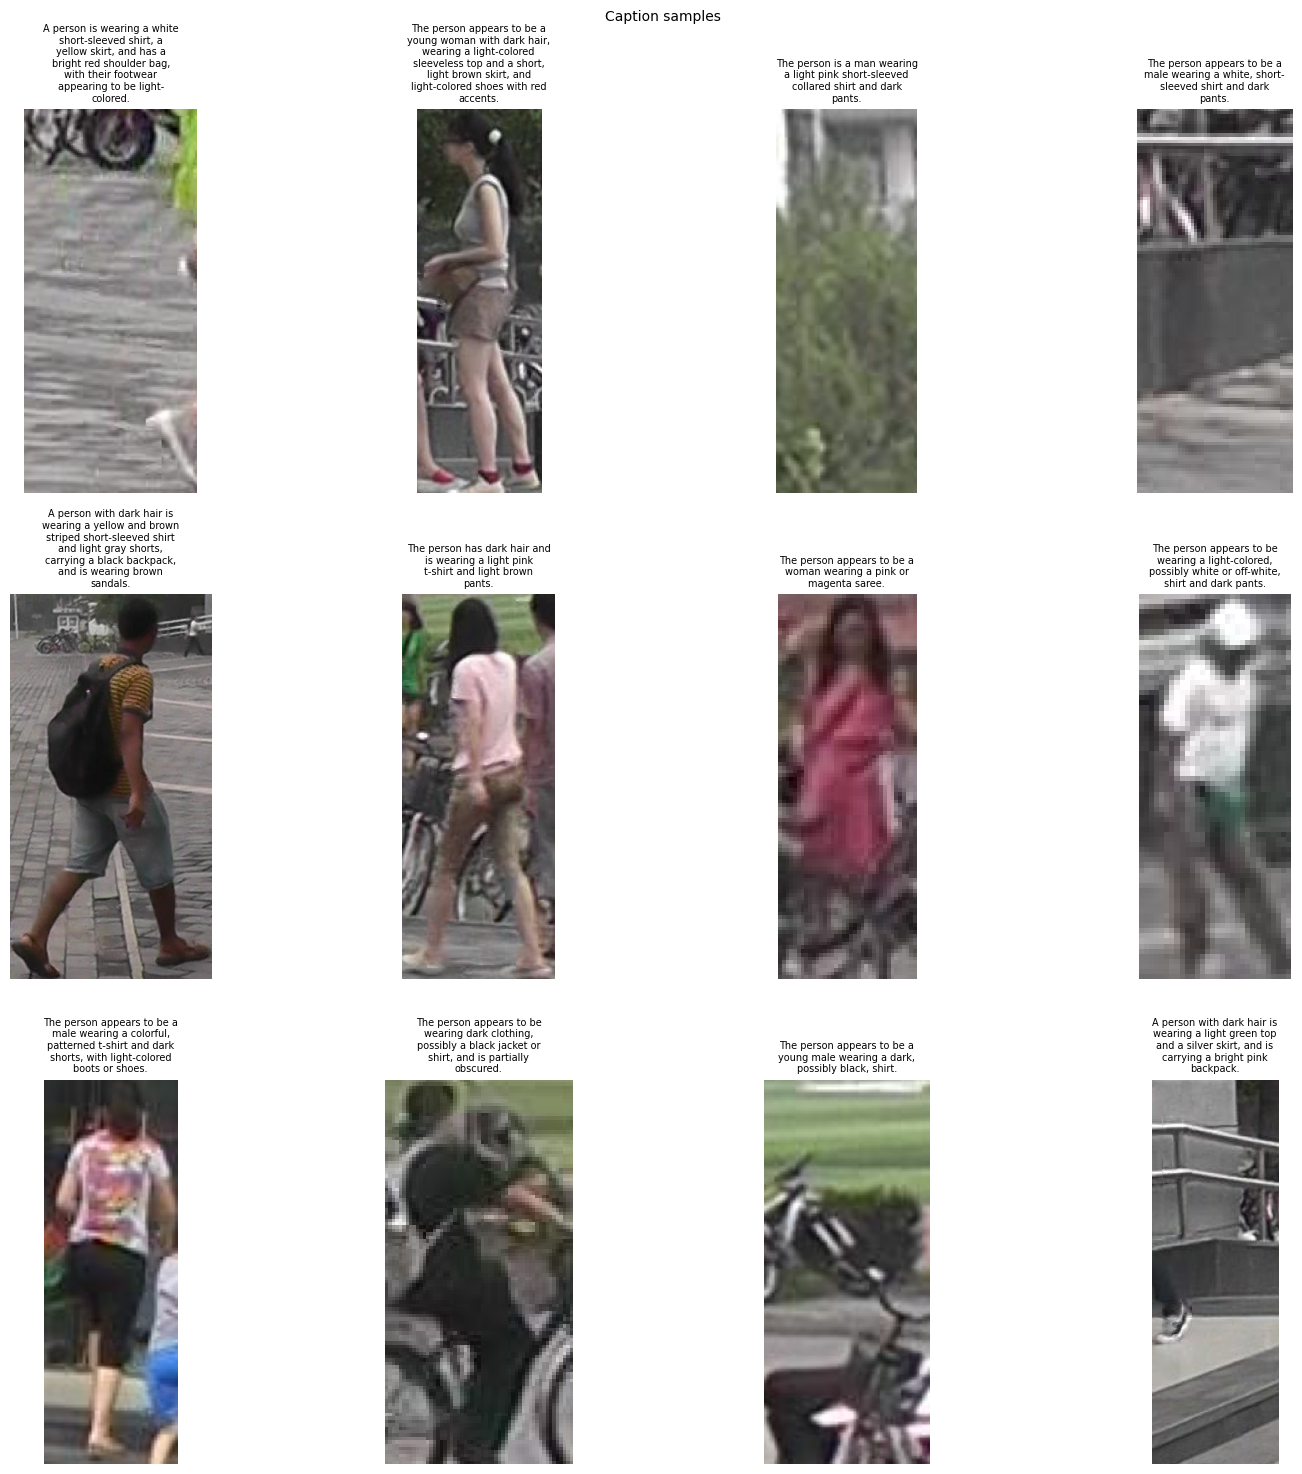

In [ ]:
plot_caption_samples()

### debug
to compare 2 different captionings

In [ ]:
# with open("train_cache/gallery_caps_C.json", "r") as f:
#     full_caps = json.load(f)
# # with open("train_cache/gallery_caps_C_1.json", "r") as f:
# #     lighter_caps = json.load(f)

In [ ]:
# [c for caps in full_caps for c in caps]

In [ ]:
# full_caps = [c for caps in full_caps for c in caps]
# lighter_caps = [c for caps in lighter_caps for c in caps]
# zipped_caps = zip(full_caps, lighter_caps)
# for full, light in zipped_caps:
#     print(f"{full} - VS - {light}")

## 6. Query Processing

Query images are pre-cropped in `dataset/query_box/` — no detection step needed. We extract the same features as for gallery crops and fuse with the same `alpha`.

Note: `img_name` in query annotations is the **source frame** name (used by eval for exclusion), but `get_image_path` transparently returns the crop path.

In [ ]:
Q_VIS_CACHE  = CACHE_DIR / f'query_vis_{RUN_CONFIG}.npy'
Q_CAPS_CACHE = CACHE_DIR / f'query_caps_{RUN_CONFIG}.json'
Q_TXT_CACHE  = CACHE_DIR / f'query_txt_{RUN_CONFIG}.npy'


def run_query_features(query_dataset: PRWDataset, encoder: DINOv2Encoder,
                       captioner: Optional[GemmaCaptioner],
                       text_encoder: Optional[CLIPTextEncoder],
                       alpha: float,
                       vis_cache: Path, caps_cache: Path, txt_cache: Path,
                       force: bool = False) -> list:
    """
    Extract final L2-normalized features for all 2,057 query crops.
    Returns list of M [D] float32 vectors aligned with query_dataset.annotations.
    When captioner is None (Config A), returns visual-only features.
    Otherwise always fuses (even alpha=0) to keep dims consistent with gallery.
    """
    # ── Visual features ───────────────────────────────────────────────────────
    if vis_cache.exists() and not force:
        print(f'Loading query visual features from cache: {vis_cache}')
        vis_feats = np.load(str(vis_cache))                   # [M, D_v]
    else:
        paths     = [query_dataset.get_image_path(i) for i in range(len(query_dataset))]
        vis_list  = encoder.encode_crops_from_paths(paths, desc=f'{encoder.name} (queries)', disable_progress=False)
        vis_feats = np.stack(vis_list, axis=0)                # [M, D_v]
        np.save(str(vis_cache), vis_feats)
        print(f'Saved query visual features \u2192 {vis_cache}')

    if captioner is None:
        return [vis_feats[i] for i in range(len(vis_feats))], None

    # ── Captions ──────────────────────────────────────────────────────────────
    if caps_cache.exists() and not force:
        print(f'Loading query captions from cache: {caps_cache}')
        with open(caps_cache) as f:
            captions = json.load(f)
    else:
        images   = [Image.open(query_dataset.get_image_path(i)).convert('RGB')
                    for i in range(len(query_dataset))]
        captions = captioner.caption_batch(images, desc='Gemma captioning (queries)')
        with open(caps_cache, 'w') as f:
            json.dump(captions, f)
        print(f'Saved query captions \u2192 {caps_cache}')

    # ── Text features ─────────────────────────────────────────────────────────
    if txt_cache.exists() and not force:
        print(f'Loading query text features from cache: {txt_cache}')
        txt_feats = np.load(str(txt_cache))                   # [M, D_t]
    else:
        txt_feats = text_encoder.encode_texts(captions)
        np.save(str(txt_cache), txt_feats)
        print(f'Saved query text features \u2192 {txt_cache}')

    # ── Fuse (always fuse when captioner present, for consistent dims) ────────
    fused = fuse_features(vis_feats, txt_feats, alpha)        # [M, D_v + D_t]

    captions = polish_caps(captions, is_query=True) # to remove noise from captions

    return [fused[i] for i in range(len(fused))], captions

In [ ]:
query_box_feats, query_caps = run_query_features(
    query_dataset,
    encoder=dino_enc,
    captioner=captioner if cfg['caption'] else None,
    text_encoder=text_encoder if cfg['caption'] else None,
    alpha=ALPHA,
    vis_cache=Q_VIS_CACHE,
    caps_cache=Q_CAPS_CACHE,
    txt_cache=Q_TXT_CACHE,
)
print(f'query_box_feats[0].shape = {query_box_feats[0].shape}')
print(f'Total queries: {len(query_box_feats)}')

Loading query visual features from cache: train_cache/query_vis_C.npy


Gemma captioning (queries):   0%|          | 0/1374 [00:00<?, ?it/s]

Gemma captioning (queries): 100%|██████████| 1374/1374 [24:15<00:00,  1.06s/it]


Saved query captions → train_cache/query_caps_C.json
Saved query text features → train_cache/query_txt_C.npy
Removed 58 captions.
query_box_feats[0].shape = (1792,)
Total queries: 1374


## 7. Evaluation

`eval_search_prw` evaluates person search performance:
- For each query, ranks all gallery detections by cosine similarity to the query feature
- Labels a detection as TP if IoU ≥ threshold with the ground-truth box for that person
- Computes per-query Average Precision, scaled by detection recall rate (penalizes missed detections)
- Returns **mAP** and **top-1 accuracy**

In [ ]:
print(f"\n{'=' * 60}")
print(f'Config {RUN_CONFIG} | det_thresh={DET_THRESH} | alpha={ALPHA}')
print('=' * 60)

results = eval_search_prw(
    gallery_dataset=gallery_dataset,
    query_dataset=query_dataset,
    gallery_dets=gallery_dets,
    gallery_feats=gallery_feats,
    query_box_feats=query_box_feats,
    det_thresh=DET_THRESH,
)

# Save scalar metrics (strip non-serialisable numpy arrays)
out = {k: v.tolist() if isinstance(v, np.ndarray) else v
       for k, v in results.items() if k != 'results'}
results_path = CACHE_DIR / f'results_{RUN_CONFIG}_alpha{ALPHA}.json'
with open(results_path, 'w') as f:
    json.dump(out, f, indent=2)
print(f'\nResults saved \u2192 {results_path}')


Config C | det_thresh=0.3 | alpha=0.5
search ranking:
  mAP = 4.09%
  top- 1 = 5.12%
recall rate: 0.5

Results saved → train_cache/results_C_alpha0.5.json


In [ ]:
# ============================================================
# TRAIN PROMPT CONCISE
# ============================================================
# search ranking:
#   mAP = 18.24%
#   top- 1 = 41.67%
# recall rate: 1.0

# Results saved → train_cache/results_C_alpha0.5.json

In [ ]:
# ============================================================
# TIPSv2 Encoder with pooled vis feature
# ============================================================
# search ranking:
#   mAP = 19.17%
#   top- 1 = 49.73%
# recall rate: 0.9375


# ============================================================
# TIPSv2 Encoder with CLS vis feature
# ============================================================
# search ranking:
#   mAP = 22.89%
#   top- 1 = 57.95%
# recall rate: 0.9375


# ============================================================
# SigLIP2Encoder
# ============================================================
# search ranking:
#   mAP = 16.13%
#   top- 1 = 48.86%
# recall rate: 0.9375


# ============================================================
# CLIPEncoder (both images and text)
# ============================================================
# search ranking:
#   mAP = 11.52%
#   top- 1 = 40.64%
# recall rate: 0.9375


# ============================================================
# DINOV3 - BGEM3TextEncoder (strong top-1 accuracy)
# ============================================================
# search ranking:
#   mAP = 10.91%
#   top- 1 = 54.25%
# recall rate: 0.9375

# FROM HERE ON WE PROVED ALPHA=0.5 AND PATCHES TO BE OPTIMAL.

# ============================================================
# DINOV3 - CLIP - ONLY PATCHES AND VISUAL FEATURES WITH MEAN ON LAST_HIDDEN_LAYER, ALPHA=0.5
# ============================================================
# search ranking:
#   mAP = 13.01%
#   top- 1 = 51.73%
# recall rate: 0.9375

# Results saved → test_cache/results_C_alpha0.5.json

# ============================================================
# DINOV3 - CLIP - ONLY PATCHES AND VISUAL FEATURES, ALPHA=0.5
# ============================================================
# search ranking:
#   mAP = 12.87%
#   top- 1 = 52.89%
# recall rate: 0.9375

# ============================================================
# DINOV2 - CLIP - ONLY PATCHES AND VISUAL FEATURES, ALPHA=1
# ============================================================
# search ranking:
#   mAP = 9.94%
#   top- 1 = 45.55%
# recall rate: 0.9375

# Results saved → cache/results_C_alpha1.json

# ============================================================
# Config C | DINOV2 - PATCHES AND CLS, ALPHA=0
# ============================================================
# search ranking:
#   mAP = 3.23%
#   top- 1 = 25.33%
# recall rate: 0.9375

# Results saved → cache/results_C_alpha0.json

# ============================================================
# Config C | DINOV2 - ONLY PATCHES, ALPHA=0
# ============================================================
# search ranking:
#   mAP = 4.11%
#   top- 1 = 30.82%
# recall rate: 0.9375

# Results saved → cache/results_C_alpha0.json

# ============================================================
# Config C | DINOV2 - ONLY PATCHES, ALPHA=1
# ============================================================
# search ranking:
#   mAP = 9.91%
#   top- 1 = 46.23%
# recall rate: 0.9375

# Results saved → cache/results_C_alpha1.json

# ============================================================
# Config C | DINOV3
# ============================================================
# search ranking:
#   mAP = 7.18%
#   top- 1 = 41.23%
# recall rate: 0.9375

# Results saved → cache/results_C_alpha1.json

# ============================================================
# Config C | DINOV2
# ============================================================
# search ranking:
#   mAP = 7.56%
#   top- 1 = 40.30%
# recall rate: 0.9375

# Results saved → cache/results_C_alpha1.json

In [27]:
# ============================================================
# DINOV2
# ============================================================
# search ranking:
#   mAP = 2.87%
#   top- 1 = 22.80%
# recall rate: 1.0

# Results saved → cache/results_B_alpha0.json

# ============================================================
# DINOV3
# ============================================================
# search ranking:
#   mAP = 2.82%
#   top- 1 = 25.47%
# recall rate: 1.0

# Results saved → cache/results_B_alpha0.json

In [28]:
# ============================================================
# Config B | det_thresh=0.5 | alpha=0.5
# ============================================================
# search ranking:
#   mAP = 2.87%
#   top- 1 = 22.80%
# recall rate: 1.0

# Results saved → cache/results_B_alpha0.5.json

In [29]:
# ============================================================
# Config B | det_thresh=0.3 | alpha=1
# ============================================================
# search ranking:
#   mAP = 7.56%
#   top- 1 = 40.30%
# recall rate: 0.9375

# Results saved → cache/results_B_alpha1.json

## 8. Alpha Sweep (Configs B & C only)

Sweep the `alpha` text-feature weight to find the optimal balance between DINOv2 visual features and CLIP text features. Reuses cached visual and text feature arrays — no model re-runs needed.

In [30]:
def run_alpha_sweep(gallery_vis_feats: list, gallery_text_feats: list,
                    gallery_dets: list, gallery_dataset: PRWDataset,
                    query_dataset: PRWDataset, q_vis: np.ndarray, q_text: np.ndarray,
                    alphas: list, det_thresh: float = DET_THRESH) -> dict:
    """
    Sweep alpha values and return {alpha: {'mAP': ..., 'top1': ...}}.
    For each alpha, fuses cached features and runs eval_search_prw.
    """
    sweep = {}
    for alpha in alphas:
        print(f'\n--- alpha = {alpha} ---')
        gf     = build_final_gallery_feats(gallery_vis_feats, gallery_text_feats, alpha)
        q_fuse = fuse_features(q_vis, q_text, alpha)       # [M, D_v + D_t]
        qf     = [q_fuse[i] for i in range(len(q_fuse))]
        res    = eval_search_prw(
            gallery_dataset, query_dataset, gallery_dets, gf, qf, det_thresh
        )
        sweep[alpha] = {'mAP': float(res['mAP']), 'top1': float(res['accs'][0])}
    return sweep

In [ ]:
if cfg['caption'] and gallery_text_feats is not None:
    ALPHAS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    q_vis  = np.load(str(Q_VIS_CACHE))
    q_text = np.load(str(Q_TXT_CACHE))

    sweep = run_alpha_sweep(
        gallery_vis_feats, gallery_text_feats,
        gallery_dets, gallery_dataset, query_dataset,
        q_vis, q_text, ALPHAS,
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(ALPHAS, [sweep[a]['mAP']  for a in ALPHAS], 'o-')
    ax2.plot(ALPHAS, [sweep[a]['top1'] for a in ALPHAS], 's-', color='tab:orange')
    ax1.set(xlabel='alpha', ylabel='mAP',   title='mAP vs alpha')
    ax2.set(xlabel='alpha', ylabel='Top-1', title='Top-1 vs alpha')
    for ax in (ax1, ax2):
        ax.grid(True, linestyle='--', alpha=0.5)
    plt.suptitle(f'Config {RUN_CONFIG}: text-feature weight sweep')
    plt.tight_layout()
    plt.savefig(str(CACHE_DIR / f'alpha_sweep_{RUN_CONFIG}.png'), dpi=120)
    plt.show()
    best_alpha = max(sweep, key=lambda a: sweep[a]['mAP'])
    print(f'Best alpha by mAP: {best_alpha}  →  mAP={sweep[best_alpha]["mAP"]:.4f}')
else:
    print('Alpha sweep only available for Configs B and C (caption=True).')

## 9. Qualitative Visualization

Display query crops alongside top-5 gallery retrievals. Green bounding box = correct match (IoU ≥ threshold); red = wrong.

### to do: here you have to add the caption to each detection (you decide where, as a title of the image or other nice ways.)

In [35]:
def visualize_query_results(results: dict, n_queries: int = 3, top_k: int = 5) -> None:
    import random, textwrap
    img_root    = results['image_root']
    sample      = random.sample(results['results'], n_queries)
    ann_by_name = {a['img_name']: i for i, a in enumerate(query_dataset.annotations)}

    g_caps = gallery_caps if cfg['caption'] else None
    q_caps = query_caps if cfg['caption'] else None

    frame_to_idx = {a['img_name']: i for i, a in enumerate(gallery_dataset.annotations)}

    def _cap_for_hit(hit: dict) -> str:
        if g_caps is None:
            return ''
        fi = frame_to_idx.get(hit['img'], -1)
        if fi < 0 or len(gallery_dets[fi]) == 0:
            return ''
        roi = np.array(hit['roi'][:4], dtype=np.float64)
        diffs = np.abs(gallery_dets[fi][:, :4].astype(np.float64) - roi)
        matches = np.where(np.all(diffs < 0.5, axis=1))[0]
        if len(matches) == 0:
            return ''
        return g_caps[fi][int(matches[0])]

    for entry in sample:
        fig, axes = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 5))

        q_idx = ann_by_name.get(entry['query_img'], 0)
        axes[0].imshow(Image.open(query_dataset.get_image_path(q_idx)))
        q_caption = q_caps[q_idx] if q_caps is not None else ''
        q_cap_line = ('\n' + '\n'.join(textwrap.wrap(q_caption, width=28))) if q_caption else ''
        axes[0].set_title(f'Query\n{q_cap_line}', fontsize=7)
        axes[0].axis('off')

        for k, hit in enumerate(entry['gallery'][:top_k]):
            frame = Image.open(os.path.join(img_root, hit['img']))
            axes[k + 1].imshow(frame)
            x1, y1, x2, y2 = hit['roi'][:4]
            color = 'lime' if hit['correct'] else 'red'
            axes[k + 1].add_patch(
                patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor=color, facecolor='none',
                )
            )
            caption = _cap_for_hit(hit)
            cap_line = ('\n' + '\n'.join(textwrap.wrap(caption, width=35))) if caption else ''
            axes[k + 1].set_title(
                f'#{k+1} {chr(10003) if hit["correct"] else chr(10007)}\n{hit["score"]:.3f}{cap_line}',
                fontsize=7, color=color,
            )
            axes[k + 1].axis('off')

        plt.suptitle(f'Query source: {entry["query_img"]}', fontsize=9)
        plt.tight_layout()
        plt.show()

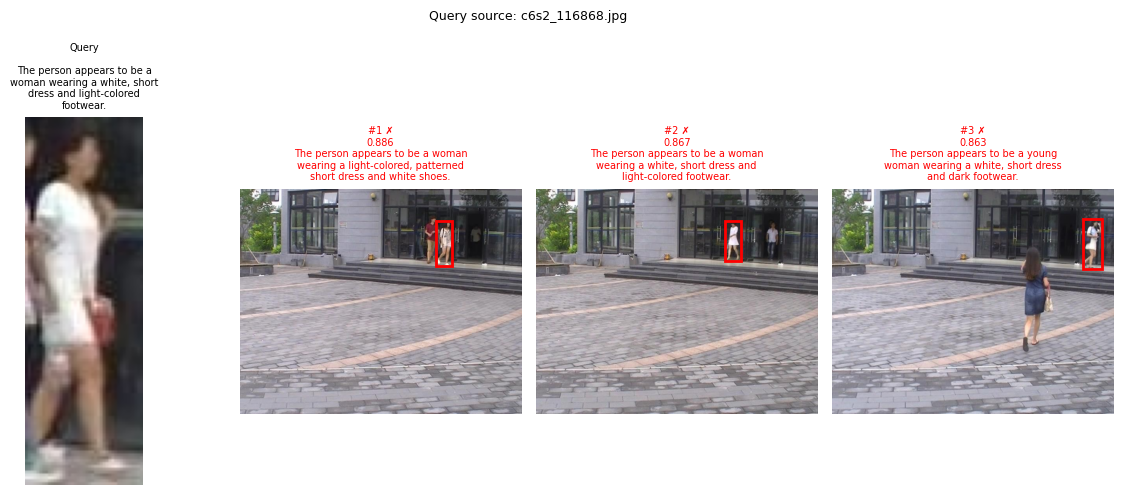

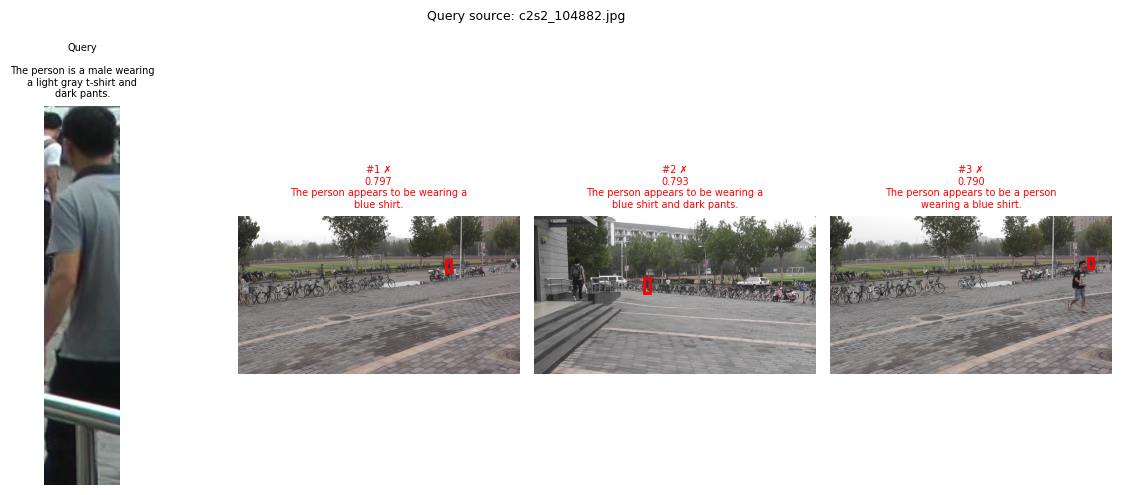

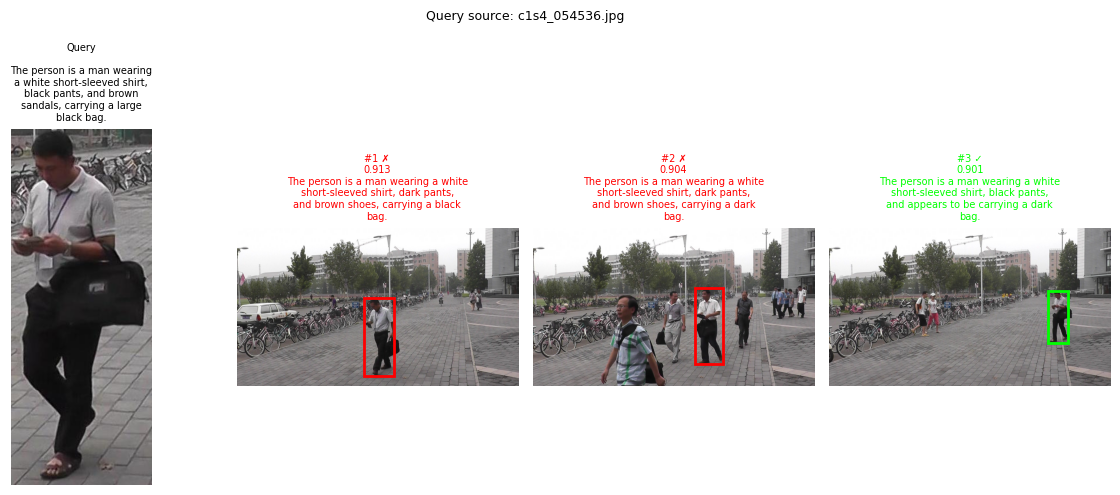

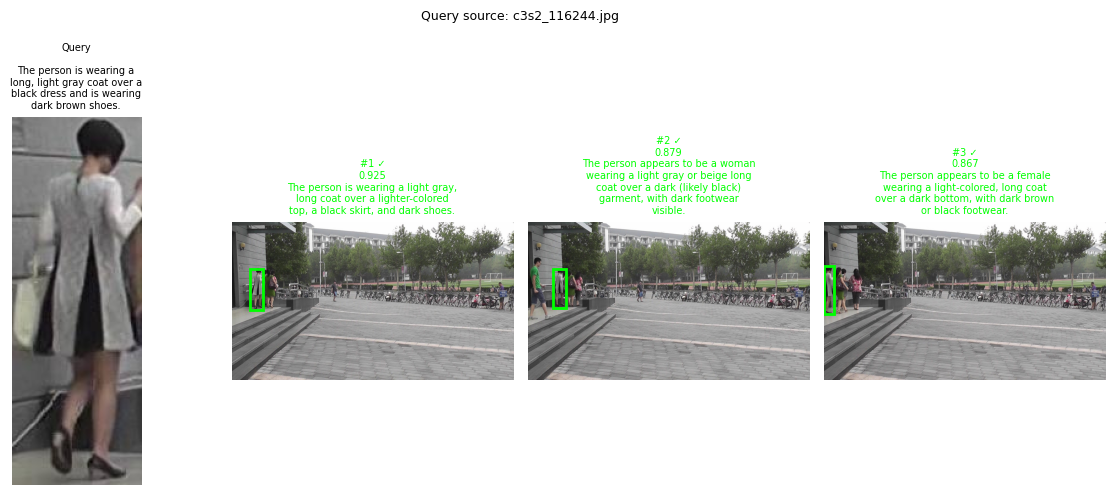

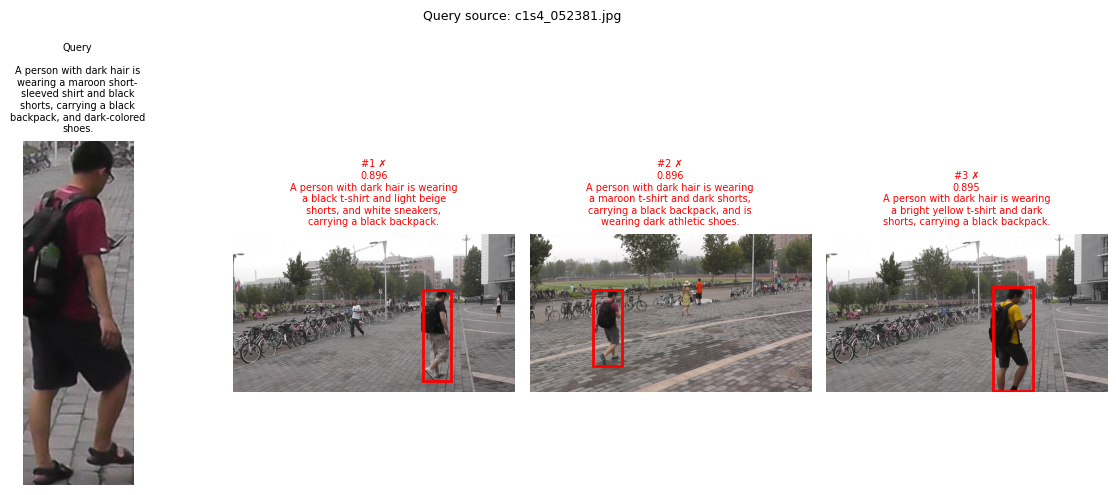

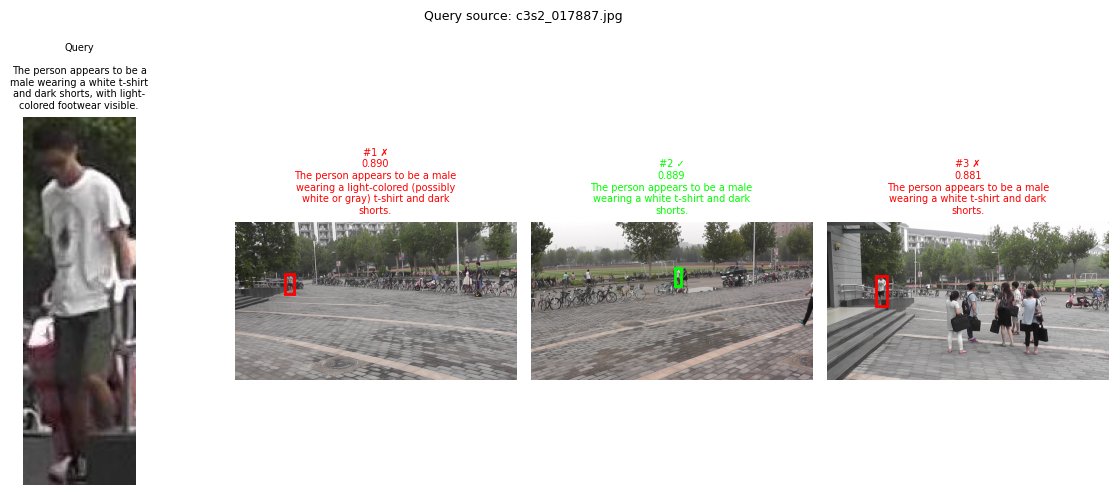

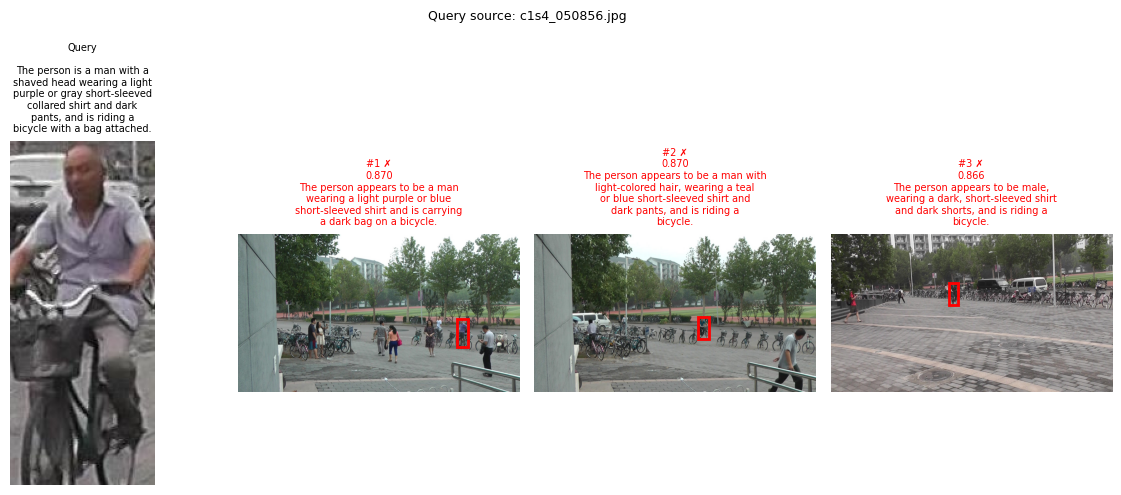

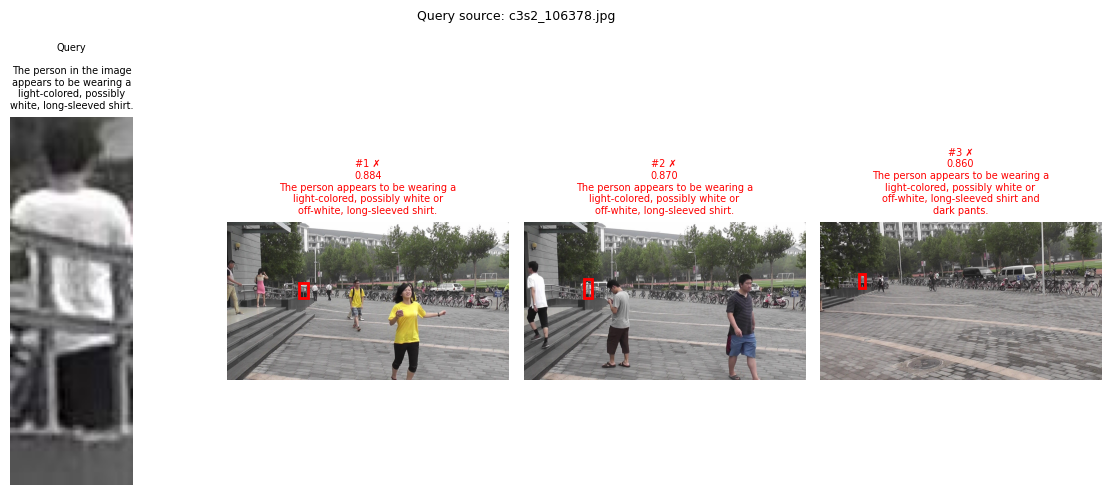

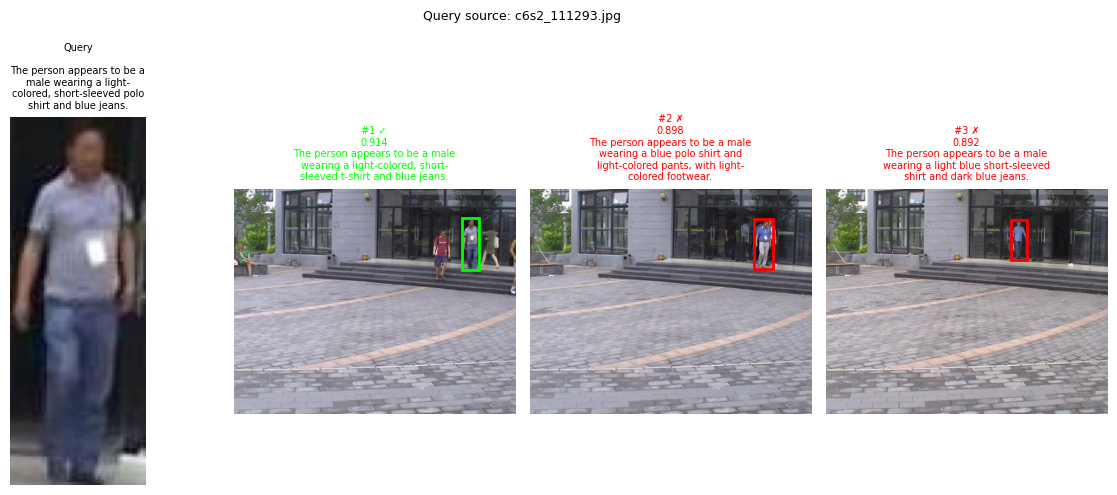

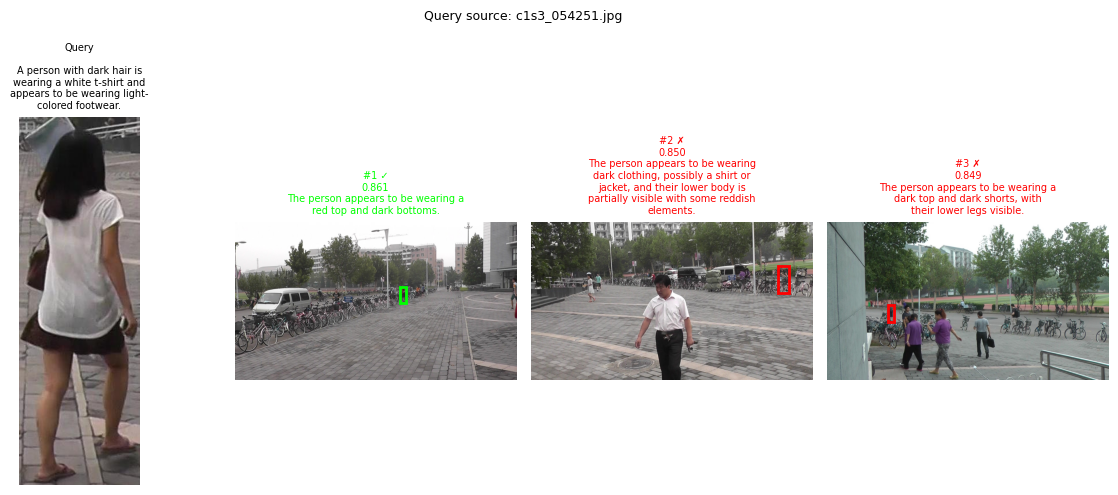

In [38]:
visualize_query_results(results, n_queries=10, top_k=3)